# Toy 2D Bayesian Posterior (Matplotlib)

Define a custom log-likelihood on x = (x1, x2) using a nonlinear (near-identity) map and combine it with a Gaussian prior.

In [2]:
import os
import sys

import numpy as np

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D

## Custom Likelihood
Use a near-identity, nonlinear map f(x) and a Gaussian error model on f(x).

In [ ]:
def f_nonlinear(x):
    x1, x2 = x
    return np.array([x1 + 0.3 * np.sin(x2), x2 + 0.3 * np.sin(x1)])

def f_quadratic_shear(x, exp1=1, exp2=2):
    """Globally invertible"""
    x1, x2 = x
    return np.array([x1**exp1, x1 + x2 ** exp2])

def f_polar_twist(x, alpha):
    x1, x2 = x
    radius = np.sqrt(x1 ** 2 + x2 ** 2)
    comp1 = x1 * np.cos(alpha * radius) - x2 * np.sin(alpha * radius)
    comp2 = x1 * np.sin(alpha * radius) + x2 * np.cos(alpha * radius)
    return np.array([comp1, comp2])

y_obs = np.array([0.5, -0.25])
sigma = 0.3
exp2 = 5


def log_likelihood(x):
    r = f_nonlinear(x) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

def log_likelihood_shear(x):
    r = f_quadratic_shear(x, exp2=exp2) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

def log_likelihood_polar_twist(x, y_obs, sigma=0.3, alpha=0.5):
    r = f_polar_twist(x, alpha=alpha) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

In [4]:
prior_mean = np.zeros(2)
prior_cov = np.array([[1.0, 0.3], [0.3, 1]])

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

problem_shear = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood_shear,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))
print('Log-posterior (shear) at prior mean:', problem_shear.log_posterior(prior_mean))

Log-posterior at prior mean: -1.7361111111111112
Log-posterior (shear) at prior mean: -1.7361111111111112


## Ellipses

The pCN (Neal) proposal
$$
x^{\star} = \rho x + \sqrt{1-\rho^2}\nu, \quad \nu \sim N(0, C), \quad \rho \in [0, 1]
$$
defines a quarter of an ellipse (plotted in solid gray). 
In the ESS paper they use \rho \in [0, 1], this defines half of an ellipse. 

The ESS proposal
$$
x^{\star} = x \cos(\theta) + \nu \sin(\theta), \quad \nu \sim N(0, C), \quad \theta \in [0, 2\pi]
$$
defines a full ellipse. This widens the search for each iteration. 

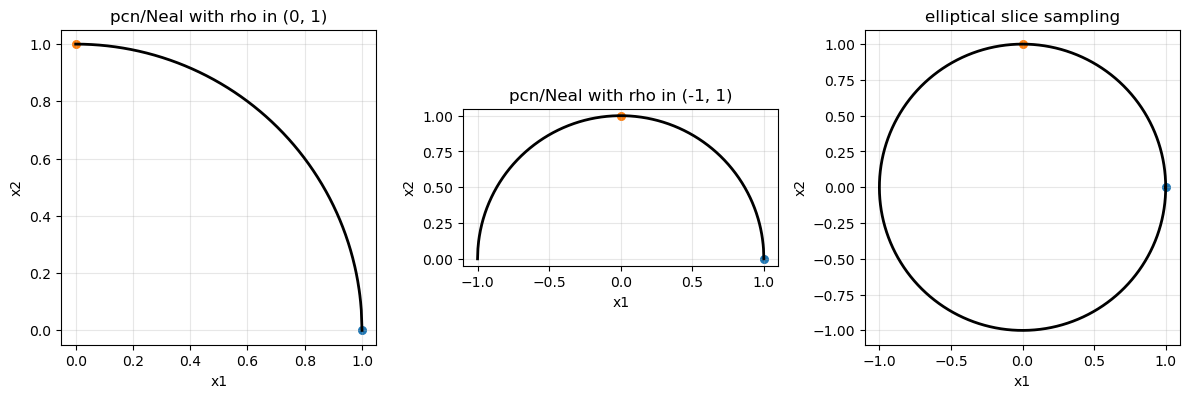

In [7]:
# Here add three ellipses: one for rho in (0, 1), one for rho in (-1, 1), and one the full ellipse with the cos, sin parametrization with theta in 0, 2pi
import matplotlib.pyplot as plt

x0 = np.array([1.0, 0.0])
nu = np.array([0.0, 1.0])

rho_pos = np.linspace(0.0, 1.0, 400)
rho_full = np.linspace(-1.0, 1.0, 800)
theta = np.linspace(0.0, 2.0 * np.pi, 800)

pcn_pos = rho_pos[:, None] * x0 + np.sqrt(1.0 - rho_pos**2)[:, None] * nu
pcn_full = rho_full[:, None] * x0 + np.sqrt(1.0 - rho_full**2)[:, None] * nu
ess = np.cos(theta)[:, None] * x0 + np.sin(theta)[:, None] * nu

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = [
    'pcn/Neal with rho in (0, 1)',
    'pcn/Neal with rho in (-1, 1)',
    'elliptical slice sampling',
]
curves = [pcn_pos, pcn_full, ess]

for ax, title, curve in zip(axes, titles, curves):
    ax.plot(curve[:, 0], curve[:, 1], color='black', linewidth=2)
    ax.scatter([x0[0]], [x0[1]], color='tab:blue', s=30)
    ax.scatter([nu[0]], [nu[1]], color='tab:orange', s=30)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
rho_vals = np.cos(np.linspace(0.0, 2.0 * np.pi, 800))
rho_mask = (rho_vals >= 0) & (rho_vals <= 1)
rho_mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

rho: 0.3462874999237423
slice_mask sum: 288 / 800 (36.00%)
slice_mask sum: 71 / 800 (8.88%)
slice_mask sum: 103 / 800 (12.88%)


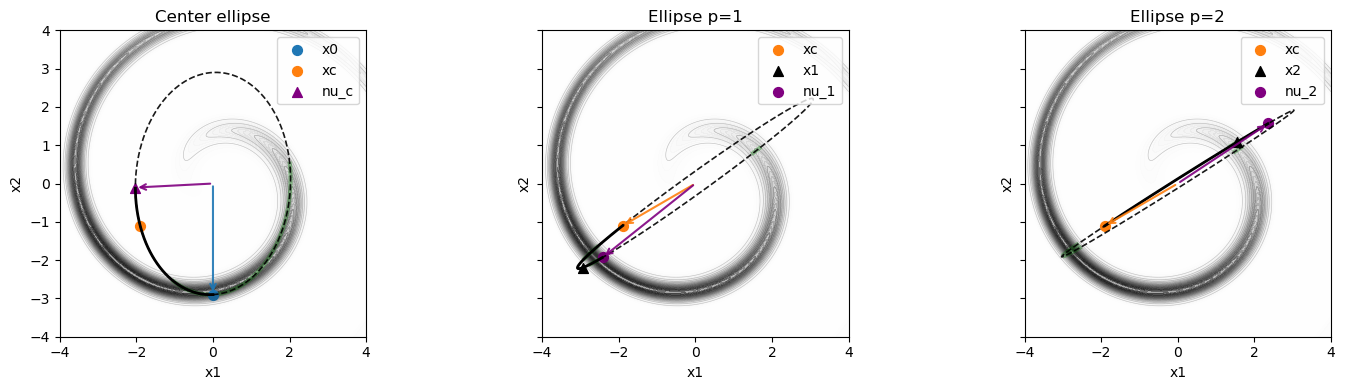

In [48]:
# Ellipses with likelihood contours (separate subplots)
import matplotlib.pyplot as plt

# Configure hyperpars and create some data
alpha = 2.0
sigma_noise = 1
prior_std = 2
prior_cov = prior_std ** 2  * np.array([[1.0, 0.3], [0.3, 0.5]])
prior_mean = np.zeros(2)

# Rho and P configuration
rng = np.random.default_rng(202)
P = 2
rho_min = 0.0
rho_max = 1.0
rho = rng.uniform(rho_min, rho_max)
print(f"rho: {rho}")

prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_polar_twist(prior_sample, alpha=alpha)
y_obs = theta_true + rng.normal(0, sigma_noise, size=theta_true.shape)

# Likelihood background (refined contours)
grid_min = -4.0
grid_max = 4.0
grid = np.linspace(grid_min, grid_max, 400)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_polar_twist(x, y_obs, alpha=alpha, sigma=sigma_noise)
log_like -= log_like.max()
like_density = np.exp(log_like)

# Initial value
x0_manual = np.array([0.0, 1.2])
x0_manual = np.array([0, -2.9])

# Slice threshold (ESS-style)
u = rng.uniform()
log_l0 = log_likelihood_polar_twist(x0_manual, y_obs, alpha=alpha, sigma=sigma_noise)
logy = log_l0 + np.log(u)

# Center ellipse
nu_c = rng.multivariate_normal(prior_mean, prior_cov)
xc = rho * x0_manual + np.sqrt(1.0 - rho**2) * nu_c

# P ellipses
nu_ps = rng.multivariate_normal(prior_mean, prior_cov, size=P)

# Creating the P proposals and plotting the P ellipses
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

def add_origin_arrows(ax, x_vec, nu_vec, x_color, nu_color):
    ax.annotate("", xy=(x_vec[0], x_vec[1]), xytext=(0.0, 0.0),
                arrowprops=dict(arrowstyle="->", color=x_color, linewidth=1.5, alpha=0.9))
    ax.annotate("", xy=(nu_vec[0], nu_vec[1]), xytext=(0.0, 0.0),
                arrowprops=dict(arrowstyle="->", color=nu_color, linewidth=1.5, alpha=0.9))

def plot_ellipse(ax, base, nu, title, show_labels=True):
    ellipse = np.cos(theta)[:, None] * base + np.sin(theta)[:, None] * nu
    
    # To have rho between 0 and 1
    rho_vals = np.cos(theta)
    rho_mask = (rho_vals >= rho_min) & (rho_vals <= rho_max)

    # tho have sqrt(1-rho**2) between 0 and 1
    rho_vals_sin = np.sin(theta)
    rho_mask_sin = (rho_vals_sin >= rho_min) & (rho_vals_sin <= rho_max)
    rho_mask = rho_mask & rho_mask_sin

    log_likes = np.array([
        log_likelihood_polar_twist(ellipse[i], y_obs, alpha=alpha, sigma=sigma_noise)
        for i in range(ellipse.shape[0])
    ])
    slice_mask = log_likes >= logy
    print(f"slice_mask sum: {slice_mask.sum()} / {slice_mask.size} ({100.0 * slice_mask.sum() / slice_mask.size:.2f}%)")

    # Slice behind ellipse
    xs = ellipse[:, 0].copy()
    ys = ellipse[:, 1].copy()
    xs[~slice_mask] = np.nan
    ys[~slice_mask] = np.nan
    ax.plot(xs, ys, color="green", linewidth=3, alpha=0.35, zorder=1)

    # Full ellipse dashed, rho-range solid
    ax.plot(ellipse[:, 0], ellipse[:, 1], color="black", linewidth=1.2, linestyle="--", alpha=0.9, zorder=2)
    xs = ellipse[:, 0].copy()
    ys = ellipse[:, 1].copy()
    xs[~rho_mask] = np.nan
    ys[~rho_mask] = np.nan
    ax.plot(xs, ys, color="black", linewidth=2.0, zorder=3)

    ax.set_title(title)
    if show_labels:
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(False)

# Marker configuration
size_x = 50

# Center ellipse (x0_manual with nu_c)
axes[0].contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
axes[0].contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
plot_ellipse(axes[0], x0_manual, nu_c, "Center ellipse")
axes[0].scatter([x0_manual[0]], [x0_manual[1]], color="tab:blue", s=size_x, label="x0")
axes[0].scatter([xc[0]], [xc[1]], color="tab:orange", s=size_x, label="xc")
axes[0].scatter([nu_c[0]], [nu_c[1]], color="purple", marker="^", s=size_x, label="nu_c")
add_origin_arrows(axes[0], x0_manual, nu_c, "tab:blue", "purple")
axes[0].legend(loc="upper right")

# Ellipses for p = 1..P using xc and nu_p
for k, nu_p in enumerate(nu_ps, start=1):
    ax = axes[k]
    ax.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
    ax.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
    plot_ellipse(ax, xc, nu_p, f"Ellipse p={k}")
    xp = rho * xc + np.sqrt(1.0 - rho**2) * nu_p
    ax.scatter([xc[0]], [xc[1]], color="tab:orange", s=size_x, label="xc")
    ax.scatter([xp[0]], [xp[1]], color="black", s=size_x, marker="^", label=f"x{k}")
    ax.scatter([nu_p[0]], [nu_p[1]], color="purple", s=size_x, label=f"nu_{k}")
    add_origin_arrows(ax, xc, nu_p, "tab:orange", "purple")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

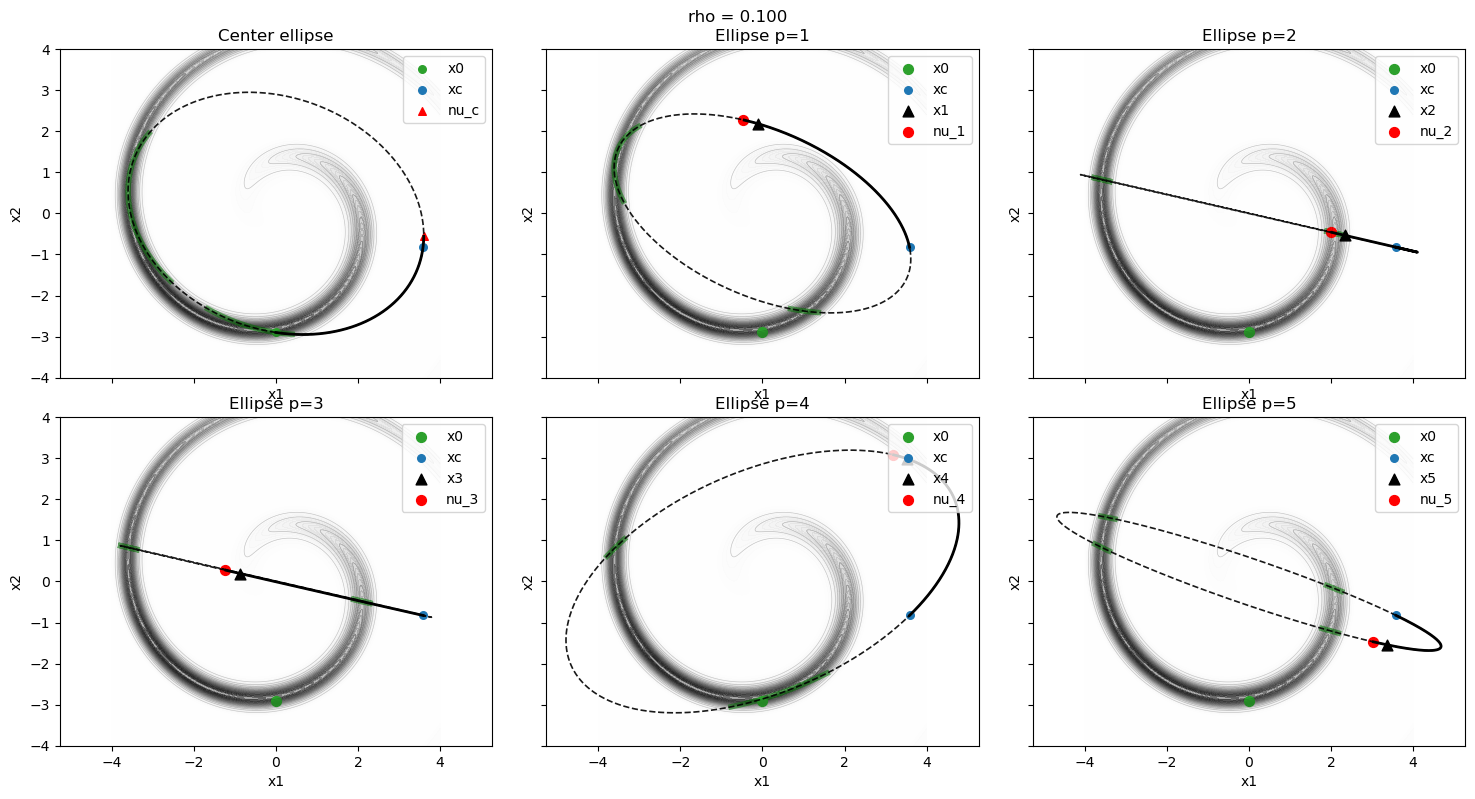

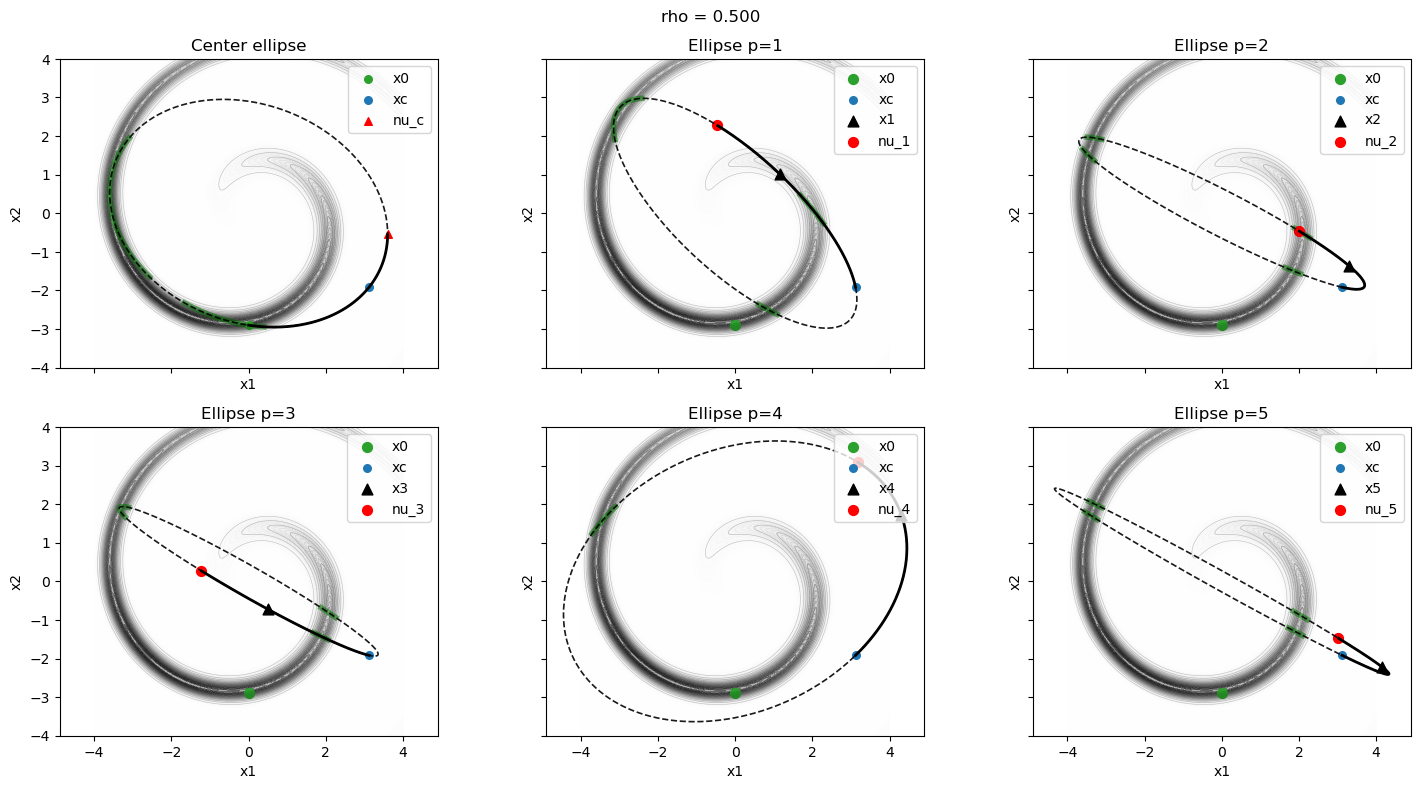

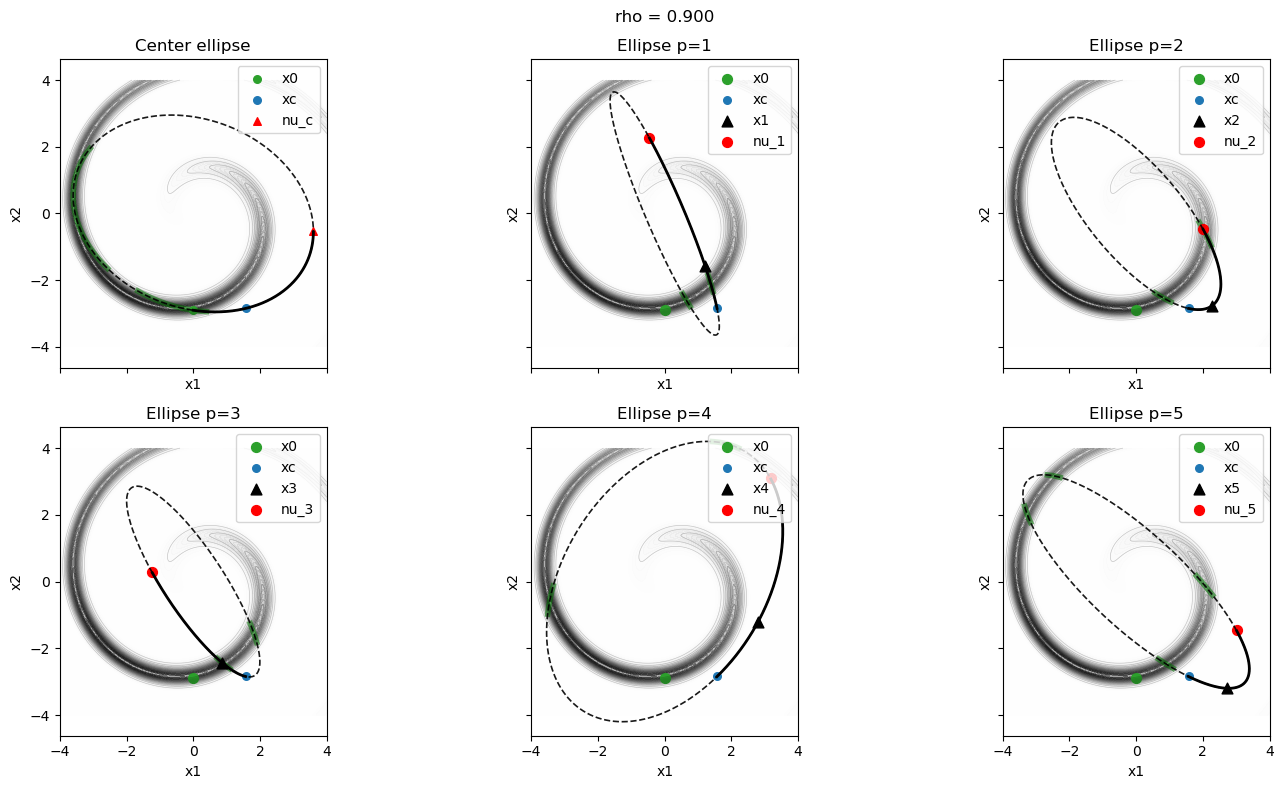

In [64]:
# Multiple rho values with P ellipses per figure (3 per row)
import math

# Configure how many ellipses and rho values to show
P_multi = 6
n_rho = 3
rho_values = np.linspace(rho_min+0.1, rho_max-0.1, n_rho)

# Ensure number of ellipses is a multiple of 3 - 1(or closest smaller)
P_eff = (P_multi // 3) * 3 - 1
if P_eff == 0:
    P_eff = min(P_multi, 3)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

# Fix nus across rho figures
nu_c = rng.multivariate_normal(prior_mean, prior_cov)
nu_ps = rng.multivariate_normal(prior_mean, prior_cov, size=P_eff)

def plot_ellipse_with_slice(ax, base, nu, logy_local):
    ellipse = np.cos(theta)[:, None] * base + np.sin(theta)[:, None] * nu
    
    # To have rho between 0 and 1
    rho_vals = np.cos(theta)
    rho_mask = (rho_vals >= rho_min) & (rho_vals <= rho_max)

    # tho have sqrt(1-rho**2) between 0 and 1
    rho_vals_sin = np.sin(theta)
    rho_mask_sin = (rho_vals_sin >= rho_min) & (rho_vals_sin <= rho_max)
    rho_mask = rho_mask & rho_mask_sin

    log_likes = np.array([
        log_likelihood_polar_twist(ellipse[i], y_obs, alpha=alpha, sigma=sigma_noise)
        for i in range(ellipse.shape[0])
    ])
    slice_mask = log_likes >= logy_local

    # Slice behind ellipse
    xs = ellipse[:, 0].copy()
    ys = ellipse[:, 1].copy()
    xs[~slice_mask] = np.nan
    ys[~slice_mask] = np.nan
    ax.plot(xs, ys, color="green", linewidth=4, alpha=0.55, zorder=1)

    # Full ellipse dashed, rho-range solid
    ax.plot(ellipse[:, 0], ellipse[:, 1], color="black", linewidth=1.2, linestyle="--", alpha=0.9, zorder=2)
    xs = ellipse[:, 0].copy()
    ys = ellipse[:, 1].copy()
    xs[~rho_mask] = np.nan
    ys[~rho_mask] = np.nan
    ax.plot(xs, ys, color="black", linewidth=2.0, zorder=3)

for rho_val in rho_values:
    log_l0 = log_likelihood_polar_twist(x0_manual, y_obs, alpha=alpha, sigma=sigma_noise)
    logy_local = log_l0 + np.log(u)

    xc = rho_val * x0_manual + np.sqrt(1.0 - rho_val**2) * nu_c

    total_plots = 1 + P_eff
    ncols = 3
    nrows = math.ceil(total_plots / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)
    fig.suptitle(f"rho = {rho_val:.3f}")

    # Center ellipse first
    ax0 = axes[0, 0]
    ax0.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
    ax0.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
    plot_ellipse_with_slice(ax0, x0_manual, nu_c, logy_local)
    ax0.scatter([x0_manual[0]], [x0_manual[1]], color="tab:green", s=30, label="x0")
    ax0.scatter([xc[0]], [xc[1]], color="tab:blue", s=30, label="xc")
    ax0.scatter([nu_c[0]], [nu_c[1]], color="red", s=30, marker="^", label="nu_c")
    ax0.set_title("Center ellipse")
    ax0.set_aspect("equal", adjustable="box")
    ax0.grid(False)
    ax0.set_xlabel("x1")
    ax0.set_ylabel("x2")
    ax0.legend(loc="upper right")

    # Ellipses p = 1..P_eff
    for idx in range(P_eff):
        plot_idx = idx + 1
        r = plot_idx // ncols
        c = plot_idx % ncols
        ax = axes[r, c]
        ax.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
        ax.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
        plot_ellipse_with_slice(ax, xc, nu_ps[idx], logy_local)
        xp = rho_val * xc + np.sqrt(1.0 - rho_val**2) * nu_ps[idx]
        ax.scatter([x0_manual[0]], [x0_manual[1]], color="tab:green", s=50, label="x0")
        ax.scatter([xc[0]], [xc[1]], color="tab:blue", s=30, label="xc")
        ax.scatter([xp[0]], [xp[1]], color="black", s=60, marker="^", label=f"x{idx + 1}")
        ax.scatter([nu_ps[idx][0]], [nu_ps[idx][1]], color="red", s=50, label=f"nu_{idx + 1}")
        ax.set_title(f"Ellipse p={idx + 1}")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(False)
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.legend(loc="upper right")

    # Hide unused axes if any
    for extra in range(total_plots, nrows * ncols):
        r = extra // ncols
        c = extra % ncols
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

rho=0.10: 0 / 5 x_p above threshold
rho=0.50: 0 / 5 x_p above threshold
rho=0.90: 1 / 5 x_p above threshold
rho 0.1 0.3 0.5 0.7 0.9
P=2     0.500 0.000 0.000 0.000 0.500
P=10    0.300 0.000 0.000 0.000 0.200
P=50    0.000 0.200 0.040 0.060 0.180
P=100   0.240 0.020 0.110 0.090 0.100
P=200   0.105 0.065 0.055 0.090 0.415
P=500   0.014 0.052 0.170 0.134 0.198
P=1000  0.080 0.067 0.056 0.070 0.447
P=5000  0.144 0.069 0.198 0.150 0.437
P=10000 0.029 0.049 0.132 0.135 0.134
P=20000 0.020 0.301 0.085 0.227 0.339
P=50000 0.038 0.112 0.085 0.147 0.100


/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_12073/2164365404.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn")
/var/folders/jw/64vkfdg1407__zgldz2hpjfr0000gn/T/ipykernel_12073/2164365404.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


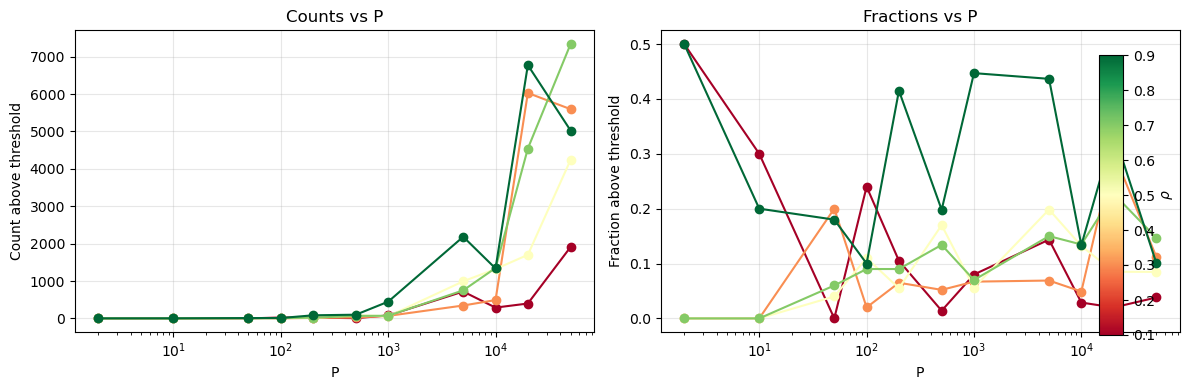

In [84]:
# Count how many x_p exceed the threshold for each rho in the multi-rho figure
log_l0 = log_likelihood_polar_twist(x0_manual, y_obs, alpha=alpha, sigma=sigma_noise)
for rho_val in rho_values:
    u_local = rng.uniform()
    logy_local = log_l0 + np.log(u_local)
    xc = rho_val * x0_manual + np.sqrt(1.0 - rho_val**2) * nu_c
    xps = rho_val * xc + np.sqrt(1.0 - rho_val**2) * nu_ps
    log_like_xp = np.array([
        log_likelihood_polar_twist(xps[i], y_obs, alpha=alpha, sigma=sigma_noise)
        for i in range(xps.shape[0])
    ])
    count = int((log_like_xp >= logy_local).sum())
    print(f"rho={rho_val:.2f}: {count} / {xps.shape[0]} x_p above threshold")

# Grid sweep for P and rho (no ellipse plotting)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

P_list = [2, 10, 50, 100, 200, 500, 1000, 5000, 10000, 20000, 50000]
rho_list = np.arange(0.1, 1.0, 0.2)
rng_grid = np.random.default_rng(202)
log_l0 = log_likelihood_polar_twist(x0_manual, y_obs, alpha=alpha, sigma=sigma_noise)

results_counts = {}
results_frac = {}
for P in P_list:
    nu_c_grid = rng_grid.multivariate_normal(prior_mean, prior_cov)
    nu_ps_grid = rng_grid.multivariate_normal(prior_mean, prior_cov, size=P)
    counts = []
    fracs = []
    for rho_val in rho_list:
        u_local = rng_grid.uniform()
        logy_local = log_l0 + np.log(u_local)
        xc = rho_val * x0_manual + np.sqrt(1.0 - rho_val**2) * nu_c_grid
        xps = rho_val * xc + np.sqrt(1.0 - rho_val**2) * nu_ps_grid
        log_like_xp = np.array([
            log_likelihood_polar_twist(xps[i], y_obs, alpha=alpha, sigma=sigma_noise)
            for i in range(xps.shape[0])
        ])
        count = int((log_like_xp >= logy_local).sum())
        counts.append(count)
        fracs.append(count / P)
    results_counts[P] = counts
    results_frac[P] = fracs

# Print table (fractions)
header = "rho " + " ".join([f"{r:.1f}" for r in rho_list])
print(header)
for P in P_list:
    row = " ".join([f"{c:0.3f}" for c in results_frac[P]])
    print(f"P={P:<5d} {row}")

# Prepare curves by rho
counts_by_rho = {rho_val: [] for rho_val in rho_list}
fracs_by_rho = {rho_val: [] for rho_val in rho_list}
for rho_idx, rho_val in enumerate(rho_list):
    for P in P_list:
        counts_by_rho[rho_val].append(results_counts[P][rho_idx])
        fracs_by_rho[rho_val].append(results_frac[P][rho_idx])

norm = mcolors.Normalize(vmin=rho_list.min(), vmax=rho_list.max())
cmap = cm.get_cmap("RdYlGn")
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for rho_val in rho_list:
    color = cmap(norm(rho_val))
    axes[0].plot(P_list, counts_by_rho[rho_val], marker="o", linewidth=1.5, color=color)
    axes[1].plot(P_list, fracs_by_rho[rho_val], marker="o", linewidth=1.5, color=color)

axes[0].set_xlabel("P")
axes[0].set_ylabel("Count above threshold")
axes[0].set_title("Counts vs P")
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")
axes[1].set_xlabel("P")
axes[1].set_ylabel("Fraction above threshold")
axes[1].set_title("Fractions vs P")
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale("log")

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), location="right", pad=0.2, cax=cax)
cbar.set_label("$\\rho$")
fig.tight_layout()
plt.show()

Thus in MpCN we sample P quarter ellipses and choose randomly on the P ellipses, and in MESS we sample a single ellipse (thus having access to a single slice) but we choose an optimal value on the slice.

In the example below obtained with seed2026, I show how by having the pCN proposal we lose efficiency.

Q: (fixing rho is equivalent in average to random sampling one point, I think)

What is better? to have M half ellipses, and sample one point from each of them basically at random, or to have a single ellipse, and choose smartly with M values from it? I think this is impossible to quantify because it depends on the likelihood function, but probably there are some insights we can gain by studying these questions further.

## Multiellipse Multiproposal Elliptical Slice Sampling

I propose that we can combine mPCN and MESS to derive a stronger algorithm.
The idea is to sample P ellipses at each iteration, and use MESS with M>1 to sample automatically an optimal value from each ellipse. Then, all proposals are accepted proposals, and can be recycled, and the furthest state can be used to propagate the chain.

Now let's think about the validity of MMESS. The Tjelmeland correction (the star structure) implies that we start with the current state x, then sample a new state y with a symmetrical distribution, centered at x, and then around y we sample P new states denoted by x1, ..., xP with the same symmetrical distribution, centered at y. We then accept Barker-type among the elements of x = (x0, ..., xP). This preserves reversibility because the probability for going from x to y and from y to xm, where m is the index of the accepted proposal, is the same probability as going from xm to y and from y to x, and we have conditional independence.

In mPCN, it is already proven that having the P half-ellipses following this multiproposal scheme and accepting among them defines a reversible algorithm. However, MESS always accepts, whereas mPCN allows proposals that can fall outside of the slice.

To do:
1. Write down the algorithm in latex and try to derive a proof.
2. Apply MPCN to my likelihood example and the toy transport.
3. Apply MESS to my likelihood example and the toy transport.
3. Code up MMESS and compare.